### 安裝套件

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np

### 匯入資料

In [2]:
file_path='./WB_Machine_Error_Event_0722_0728.xlsx'
df=pd.read_excel(file_path)
#print(df.head())
print(df.shape)

(35607, 14)


### 查看欄位名稱

In [3]:
df.columns

Index(['step_id', 'lot_id', 'equip_type', 'equip_id', 'device_name',
       'recipe_id', 'in_qty', 'ng_qty', 'start_time', 'end_time', 'location',
       'floor', 'eventmessage', 'eventcount'],
      dtype='object')

### eventcount有空值

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35607 entries, 0 to 35606
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   step_id       35607 non-null  object        
 1   lot_id        35607 non-null  object        
 2   equip_type    35607 non-null  object        
 3   equip_id      35607 non-null  object        
 4   device_name   35607 non-null  object        
 5   recipe_id     35607 non-null  object        
 6   in_qty        35607 non-null  int64         
 7   ng_qty        35607 non-null  float64       
 8   start_time    35607 non-null  datetime64[ns]
 9   end_time      35607 non-null  datetime64[ns]
 10  location      35607 non-null  object        
 11  floor         35607 non-null  object        
 12  eventmessage  31510 non-null  object        
 13  eventcount    31510 non-null  float64       
dtypes: datetime64[ns](2), float64(2), int64(1), object(9)
memory usage: 3.8+ MB


In [5]:
df.loc[df['eventmessage'].isna(),"eventcount"].value_counts(dropna=False)

eventcount
NaN    4097
Name: count, dtype: int64

In [6]:
#df.describe()

### 將eventcount空值的地方已0呈現，代表發生次數為0

In [7]:
df['eventcount']=df['eventcount'].fillna(0)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35607 entries, 0 to 35606
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   step_id       35607 non-null  object        
 1   lot_id        35607 non-null  object        
 2   equip_type    35607 non-null  object        
 3   equip_id      35607 non-null  object        
 4   device_name   35607 non-null  object        
 5   recipe_id     35607 non-null  object        
 6   in_qty        35607 non-null  int64         
 7   ng_qty        35607 non-null  float64       
 8   start_time    35607 non-null  datetime64[ns]
 9   end_time      35607 non-null  datetime64[ns]
 10  location      35607 non-null  object        
 11  floor         35607 non-null  object        
 12  eventmessage  31510 non-null  object        
 13  eventcount    35607 non-null  float64       
dtypes: datetime64[ns](2), float64(2), int64(1), object(9)
memory usage: 3.8+ MB


### 新增欄位:製造時間、不良率

In [9]:
#製造時間
df["duration_min"] = (df["end_time"] - df["start_time"]).dt.total_seconds() / 60 #除以60轉成分鐘
#不良率
# df["ng_rate"] = df["ng_qty"].div(df["in_qty"]).where(df["in_qty"] > 0)


### 觀察發生最多次的錯誤事件
EX:在錯誤事件為'PDT-UNEXPECTED-SHTL'之下，總共發生了13764的錯誤次數

In [10]:
event_summary = (
            df.groupby(["eventmessage"], as_index=False)
            .agg(
            event_count=("eventcount", "sum"),
            ))
#event_summary["ng_rate"] = (event_summary["ng_qty"] / event_summary["in_qty"])
event_summary = event_summary.sort_values("event_count",ascending=False)
print(event_summary.head())
print(event_summary.shape)

           eventmessage  event_count
28  PDT-UNEXPECTED-SHTL      13764.0
27  PDT-UNEXPECTED-NSOP      10216.0
20    PBI-WIRE-STOP-ERR       7433.0
26  PDT-UNEXPECTED-NSOL       5065.0
22         PDT-EFO-OPEN       3931.0
(39, 2)


In [11]:
# event_summary = (
#             df.groupby(["eventmessage","step_id","lot_id","equip_id","device_name"], as_index=False)
#             .agg(
#             event_count=("eventcount", "sum"),
#             ng_qty=("ng_qty", "max"),
#             in_qty=("in_qty", "max")
#             ))
# event_summary["ng_rate"] = (event_summary["ng_qty"] / event_summary["in_qty"])
# event_summary = event_summary.sort_values("event_count",ascending=False)
# print(event_summary.head())
# print(event_summary.shape)

In [12]:
# df[(df["eventmessage"]=='EFU open error') & (df['equip_id']=='WB3504')]

### 觀察最高報廢率的錯誤事件
EX:在錯誤事件為'PDT-NO-FS-DETECT'之下，總共發生了200的錯誤次數

In [13]:
# event_summary = (
#             df.groupby("eventmessage", as_index=False)
#             .agg(
#             event_count=("eventcount", "sum"),
#             equip_count=("equip_id", "nunique"),
#             lot_count=("lot_id", "nunique"),
#             ng_qty=("ng_qty", "sum"),
#             in_qty=("in_qty", "sum")
#             ))
# event_summary["ng_rate"] = (event_summary["ng_qty"] / event_summary["in_qty"])
# event_summary = event_summary.sort_values("ng_rate",ascending=False)
# print(event_summary.head())

## 錯誤事件 Pareto 分析

Pareto 分析的目的，是找出少數幾種主要錯誤是否占了大部分事件。
分析結果:前三種錯誤就佔了43.35%，分別為PDT-UNEXPECTED-SHTL、PDT-UNEXPECTED-NSOP、PBI-WIRE-STOP-ERR。

In [14]:
event_pareto = (
df.groupby("eventmessage")["eventcount"]
.sum()
.sort_values(ascending=False)
.reset_index()
)
event_pareto["percentage"] = (event_pareto["eventcount"] /event_pareto["eventcount"].sum())
event_pareto["cumulative_percentage"] = (event_pareto["percentage"].cumsum())
print(event_pareto.head(20))
main_events=event_pareto.loc[:2,['eventmessage']]['eventmessage'].tolist()
print(main_events)

                     eventmessage  eventcount  percentage  \
0             PDT-UNEXPECTED-SHTL     13764.0    0.189940   
1             PDT-UNEXPECTED-NSOP     10216.0    0.140978   
2               PBI-WIRE-STOP-ERR      7433.0    0.102574   
3             PDT-UNEXPECTED-NSOL      5065.0    0.069896   
4                    PDT-EFO-OPEN      3931.0    0.054247   
5             Ball position error      3921.0    0.054109   
6                   No tail error      3680.0    0.050783   
7           Pad nonsticking error      3666.0    0.050590   
8              PDT-WIREFEED-ERROR      3508.0    0.048410   
9          Lead nonsticking error      3383.0    0.046685   
10                 EFU open error      3048.0    0.042062   
11                  EH-PDT-SMBALL      1579.0    0.021790   
12              Spool empty error      1577.0    0.021762   
13             No bump tail error      1556.0    0.021472   
14                Ball size error      1400.0    0.019320   
15             AUTO-VLL-

In [15]:
event_pareto.head(10)

,eventmessage,eventcount,percentage,cumulative_percentage
0,PDT-UNEXPECTED-SHTL,13764.0,0.189940,0.189940
1,PDT-UNEXPECTED-NSOP,10216.0,0.140978,0.330918
2,PBI-WIRE-STOP-ERR,7433.0,0.102574,0.433492
3,PDT-UNEXPECTED-NSOL,5065.0,0.069896,0.503388
4,PDT-EFO-OPEN,3931.0,0.054247,0.557635
5,Ball position error,3921.0,0.054109,0.611744
6,No tail error,3680.0,0.050783,0.662527
7,Pad nonsticking error,3666.0,0.050590,0.713117
8,PDT-WIREFEED-ERROR,3508.0,0.048410,0.761526
9,Lead nonsticking error,3383.0,0.046685,0.808211


畫 Pareto 圖

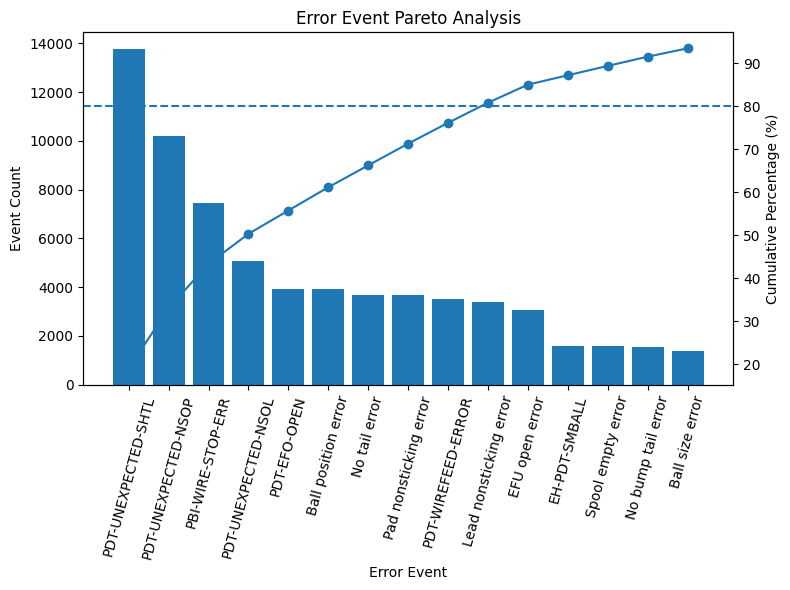

In [16]:
top_n = 15
plot_data = event_pareto.head(top_n)
#plot_data = event_pareto
fig, ax1 = plt.subplots(figsize=(8, 6))
ax1.bar(
plot_data["eventmessage"],
plot_data["eventcount"]
)
ax1.set_xlabel("Error Event")
ax1.set_ylabel("Event Count")
ax1.tick_params(axis="x", rotation=75)
ax2 = ax1.twinx()
ax2.plot(
plot_data["eventmessage"],
plot_data["cumulative_percentage"] * 100,
marker="o"
)
ax2.axhline(80, linestyle="--")
ax2.set_ylabel("Cumulative Percentage (%)")
plt.title("Error Event Pareto Analysis")
plt.tight_layout()
plt.show()

### 在這三個最常發生錯誤的事件下，分別哪些機台最常發生錯誤

In [17]:
event_machine = (
    df.loc[df['eventmessage'].isin(main_events)].groupby(["eventmessage", "equip_id"], as_index=False)
      .agg(
          event_count=("eventcount", "sum")
         # lot_count=("lot_id", "nunique"),
         # ng_qty=("ng_qty", "sum"),
         # in_qty=("in_qty", "sum")
      )
)

# event_machine["ng_rate"] = (
#     event_machine["ng_qty"] / event_machine["in_qty"]
# )
# #重點不要只看錯誤總數，因為產量高的機台錯誤數通常也會比較高。
# #更公平的比較方式是建立「每千投入量錯誤次數」。
# event_machine["events_per_1000"] = (event_machine["event_count"] /event_machine["in_qty"] * 1000)

event_machine = event_machine.sort_values(
    ["eventmessage", "event_count"],
    ascending=[True, False]
)
print(event_machine.groupby("eventmessage", group_keys=False)
    .head(3))
print(event_machine.shape)

             eventmessage equip_id  event_count
454     PBI-WIRE-STOP-ERR  WBK3150         81.0
811     PBI-WIRE-STOP-ERR  WBR2250         67.0
779     PBI-WIRE-STOP-ERR  WBR2205         56.0
1289  PDT-UNEXPECTED-NSOP  WBC6034         74.0
1390  PDT-UNEXPECTED-NSOP  WBC7035         60.0
2152  PDT-UNEXPECTED-NSOP  WBR2259         54.0
2828  PDT-UNEXPECTED-SHTL  WBC7120         98.0
2899  PDT-UNEXPECTED-SHTL  WBC7236         80.0
2812  PDT-UNEXPECTED-SHTL  WBC7035         64.0
(3821, 3)


In [18]:
# check = (
#     df.groupby("equip_id")["device_name"]
#       .nunique()
#       .reset_index(name="device_count")
# )

# print(check)

### 分析錯誤事件與產品間的關係

In [19]:
device_summary = (
df.loc[df['eventmessage'].isin(main_events)].groupby(['eventmessage',"recipe_id"], as_index=False)
.agg(
event_count=("eventcount", "sum")
# machine_count=("equip_id", "nunique"),
# lot_count=("lot_id", "nunique"),
# in_qty=("in_qty", "sum"),
# ng_qty=("ng_qty", "sum")
)
)
# device_summary["ng_rate"] = (device_summary["ng_qty"] /device_summary["in_qty"])
# device_summary["events_per_1000"] = (device_summary["event_count"] /device_summary["in_qty"] * 1000)
device_summary = device_summary.sort_values(["eventmessage","event_count"],ascending=[True,False])
print(device_summary.groupby("eventmessage", group_keys=False).head(3))

            eventmessage              recipe_id  event_count
96     PBI-WIRE-STOP-ERR  SMIM96HGG404-00-AF-00        568.0
48     PBI-WIRE-STOP-ERR  SMIM157GG407-01-AF-00        402.0
101    PBI-WIRE-STOP-ERR  SSOR89000005-00-CU-00        293.0
255  PDT-UNEXPECTED-NSOP  STSL15BGK310-00-EX-00        621.0
274  PDT-UNEXPECTED-NSOP  STSM52DGK308-00-AG-00        353.0
242  PDT-UNEXPECTED-NSOP  SMIM784G7303-00-BG-00        330.0
414  PDT-UNEXPECTED-SHTL  SMIM96HGG404-00-AF-00        738.0
439  PDT-UNEXPECTED-SHTL  STSM52DGK308-00-AG-00        519.0
338  PDT-UNEXPECTED-SHTL  SMIF004G7401-01-PO-00        477.0


在錯誤事件為'PBI-WIRE-STOP-ERR'之下，機型是WBK3150具有最高的event_count。
在錯誤事件為'PBI-WIRE-STOP-ERR'之下，產品是Y5BN8ZA64PTP31245-STK-HVM-CIP 具有最高的event_count。
現在想知道的是，WBK3150是因為Y5BN8ZA64PTP31245-STK-HVM-CIP 才具有最高的events_per_1000，還是不管生產甚麼產品都容易發生?

In [20]:
event = "PDT-UNEXPECTED-SHTL"

# --------------------------------------------------
# 1. 分子：指定錯誤事件的總發生次數
# --------------------------------------------------
event_count_summary = (
    df[df["eventmessage"] == event]
    .groupby(
        ["equip_id", "recipe_id"],
        as_index=False,
        dropna=False
    )
    .agg(
        event_count=("eventcount", "sum"),
        affected_lot_count=("lot_id", "nunique")
    )
)

# --------------------------------------------------
# 2. 分母：所有生產紀錄的實際處理量
# 每個 Step × Lot × Machine × Device 的 in_qty 只取一次
# --------------------------------------------------
production_run_summary = (
    df.groupby(
        [
            "step_id",
            "lot_id",
            "equip_id",
            "recipe_id",
            "device_name"
        ],
        as_index=False,
        dropna=False
    )
    .agg(
        in_qty=("in_qty", "max")
    )
)

# --------------------------------------------------
# 3. 彙總成 Machine × Device
# --------------------------------------------------
production_summary = (
    production_run_summary
    .groupby(
        ["equip_id", "recipe_id"],
        as_index=False,
        dropna=False
    )
    .agg(
        in_qty=("in_qty", "sum"),
        total_lot_count=("lot_id", "nunique")
    )
)

# --------------------------------------------------
# 4. 合併分子和分母
# --------------------------------------------------
machine_device_summary = production_summary.merge(
    event_count_summary,
    on=["equip_id", "recipe_id"],
    how="left"
)

machine_device_summary["event_count"] = (
    machine_device_summary["event_count"]
    .fillna(0)
)

machine_device_summary["affected_lot_count"] = (
    machine_device_summary["affected_lot_count"]
    .fillna(0)
    .astype(int)
)

# --------------------------------------------------
# 5. 每千投入錯誤次數
# --------------------------------------------------
machine_device_summary["event_per_1000"] = np.where(
    machine_device_summary["in_qty"] > 0,
    machine_device_summary["event_count"]
    / machine_device_summary["in_qty"]
    * 1000,
    np.nan
)

# --------------------------------------------------
# 6. Lot 發生率
# --------------------------------------------------
# machine_device_summary["affected_lot_rate"] = np.where(
#     machine_device_summary["total_lot_count"] > 0,
#     machine_device_summary["affected_lot_count"]
#     / machine_device_summary["total_lot_count"],
#     np.nan
# )

# --------------------------------------------------
# 7. 篩選掉太低的in_qty數量
# --------------------------------------------------
minimum_inqty_count=machine_device_summary['in_qty'].quantile(0.25)
machine_device_summary=machine_device_summary[machine_device_summary['in_qty']>=minimum_inqty_count]
# --------------------------------------------------
# 8. 排序
# --------------------------------------------------
machine_device_summary = (
    machine_device_summary
    .sort_values(
        ["event_per_1000", "event_count"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

machine_device_summary.head(20)

,equip_id,recipe_id,in_qty,total_lot_count,event_count,affected_lot_count,event_per_1000
0,WBL0025,STSL15DGK305-01-EX-02,4407,2,59.0,2,13.387792
1,WBC7236,SITM46XGX324-00-KR-01,7634,4,80.0,2,10.479434
2,WBL5203,STSM52DGK308-00-AG-00,3866,5,40.0,4,10.346611
3,WBC7120,FMIS665ML411-00-TP-00,10351,8,98.0,8,9.467684
4,WBR2036,SITM46XGX328-00-KR-04,7008,6,61.0,6,8.704338
5,WBL0026,STSL15DGK305-01-EX-02,5552,3,39.0,3,7.024496
6,WB2509,SMIM416GG410-00-PO-00,8196,9,56.0,9,6.832601
7,WBR6226,SMIM56HDG471-00-PO-02,8624,5,54.0,5,6.261596
8,WBL0145,STSM52DGK308-00-AG-00,4694,5,29.0,5,6.178100
9,WBC7215,SITM32DGX325-00-KR-00,5351,6,31.0,6,5.793310


In [21]:
# production_run_summary[production_run_summary['equip_id']=='WB2075']      

In [22]:
# # 1. 找出錯誤總次數最高的 Top 20 機台
# top20_machines = (
#     machine_device_summary
#     .groupby("equip_id")["event_count"]
#     .sum()
#     .nlargest(20)
#     .index
# )

# # 2. 找出錯誤總次數最高的 Top 20 產品A
# top20_devices = (
#     machine_device_summary
#     .groupby("device_name")["event_count"]
#     .sum()
#     .nlargest(20)
#     .index
# )

# # 3. 只保留 Top 20 機台 × Top 20 產品
# heatmap_data = machine_device_summary[
#     machine_device_summary["equip_id"].isin(top20_machines)
#     & machine_device_summary["device_name"].isin(top20_devices)
# ].copy()

# # 4. 建立 Pivot Table
# heatmap_pivot = heatmap_data.pivot(
#     index="equip_id",
#     columns="device_name",
#     values="event_per_1000"
# )

# # 按照原本 Top 20 排名順序排列
# heatmap_pivot = heatmap_pivot.reindex(
#     index=top20_machines,
#     columns=top20_devices,
#     fill_value=0
# )

# # 5. 畫 Heatmap
# fig, ax = plt.subplots(figsize=(18, 10))

# image = ax.imshow(
#     heatmap_pivot.values,
#     aspect="auto"
# )

# # 設定 X 軸產品名稱
# ax.set_xticks(range(len(heatmap_pivot.columns)))
# ax.set_xticklabels(
#     heatmap_pivot.columns,
#     rotation=90
# )

# # 設定 Y 軸機台名稱
# ax.set_yticks(range(len(heatmap_pivot.index)))
# ax.set_yticklabels(heatmap_pivot.index)

# ax.set_xlabel("Device Name")
# ax.set_ylabel("Equipment ID")
# ax.set_title(
#     f"Top 20 Machine × Top 20 Device\n"
#     f"Events per 1000 — {event}"
# )

# # 加入色階說明
# colorbar = fig.colorbar(image, ax=ax)
# colorbar.set_label("Events per 1000")

# plt.tight_layout()
# plt.show()

In [23]:
# # 1. 取 event_per_1000 最高的 Top 20 實際組合
# top20_combinations = (
#     machine_device_summary
#     .sort_values(
#         ["event_per_1000", "event_count"],
#         ascending=[False, False]
#     )
#     .head(20)
#     .copy()
# )

# # 2. 取得這 20 個組合涉及的機台和產品
# selected_machines = top20_combinations["equip_id"].unique()
# selected_devices = top20_combinations["device_name"].unique()

# # 3. 從完整 summary 中取出這些機台與產品的所有實際生產組合
# heatmap_data = machine_device_summary[
#     machine_device_summary["equip_id"].isin(selected_machines)
#     & machine_device_summary["device_name"].isin(selected_devices)
# ].copy()

# # 4. 建立 Heatmap
# heatmap_pivot = heatmap_data.pivot(
#     index="equip_id",
#     columns="device_name",
#     values="event_per_1000"
# )

# # heatmap_pivot
# fig, ax = plt.subplots(figsize=(18, 10))

# image = ax.imshow(
#     heatmap_pivot.values,
#     aspect="auto"
# )

# # 設定 X 軸產品名稱
# ax.set_xticks(range(len(heatmap_pivot.columns)))
# ax.set_xticklabels(
#     heatmap_pivot.columns,
#     rotation=90
# )

# # 設定 Y 軸機台名稱
# ax.set_yticks(range(len(heatmap_pivot.index)))
# ax.set_yticklabels(heatmap_pivot.index)

# ax.set_xlabel("Device Name")
# ax.set_ylabel("Equipment ID")
# ax.set_title(
#     f"Machine-Device Pattern Dervied from\n"
#     f"Top 20 Combinations — {event}"
# )

# # 加入色階說明
# colorbar = fig.colorbar(image, ax=ax)
# colorbar.set_label("Events per 1000")

# plt.tight_layout()
# plt.show()

In [24]:
# df.loc[ (df['device_name']=='Y5BN8ZA64PTP31245-STK-HVM-CIP')&(df['eventmessage']=='PDT-UNEXPECTED-SHTL')]

In [25]:
# df.loc[(df['equip_id']=='WB2502') & (df['device_name']=='Y5BN8ZA64PTP31245-STK-HVM-CIP')&(df['eventmessage']=='PDT-UNEXPECTED-SHTL')]

### PBI-WIRE-STOP-ERR的錯誤事件分析


In [26]:
event = "PBI-WIRE-STOP-ERR"

# --------------------------------------------------
# 1. 分子：指定錯誤事件的總發生次數
# --------------------------------------------------
event_count_summary_PBI_WIRE_STOP_ERR = (
    df[df["eventmessage"] == event]
    .groupby(
        ["equip_id", "recipe_id"],
        as_index=False,
        dropna=False
    )
    .agg(
        event_count=("eventcount", "sum"),
        affected_lot_count=("lot_id", "nunique")
    )
)

# --------------------------------------------------
# 2. 分母：所有生產紀錄的實際處理量
# 每個 Step × Lot × Machine × Device 的 in_qty 只取一次
# --------------------------------------------------
production_run_summary_PBI_WIRE_STOP_ERR = (
    df.groupby(
        [
            "step_id",
            "lot_id",
            "equip_id",
            "recipe_id",
            "device_name"
        ],
        as_index=False,
        dropna=False
    )
    .agg(
        in_qty=("in_qty", "max")
    )
)

# --------------------------------------------------
# 3. 彙總成 Machine × Device
# --------------------------------------------------
production_summary_PBI_WIRE_STOP_ERR = (
    production_run_summary_PBI_WIRE_STOP_ERR
    .groupby(
        ["equip_id", "recipe_id"],
        as_index=False,
        dropna=False
    )
    .agg(
        in_qty=("in_qty", "sum"),
        total_lot_count=("lot_id", "nunique")
    )
)

# --------------------------------------------------
# 4. 合併分子和分母
# --------------------------------------------------
machine_device_summary_PBI_WIRE_STOP_ERR = production_summary_PBI_WIRE_STOP_ERR.merge(
    event_count_summary_PBI_WIRE_STOP_ERR,
    on=["equip_id", "recipe_id"],
    how="left"
)

machine_device_summary_PBI_WIRE_STOP_ERR["event_count"] = (
    machine_device_summary_PBI_WIRE_STOP_ERR["event_count"]
    .fillna(0)
)

machine_device_summary_PBI_WIRE_STOP_ERR["affected_lot_count"] = (
    machine_device_summary_PBI_WIRE_STOP_ERR["affected_lot_count"]
    .fillna(0)
    .astype(int)
)

# --------------------------------------------------
# 5. 每千投入錯誤次數
# --------------------------------------------------
machine_device_summary_PBI_WIRE_STOP_ERR["event_per_1000"] = np.where(
    machine_device_summary_PBI_WIRE_STOP_ERR["in_qty"] > 0,
    machine_device_summary_PBI_WIRE_STOP_ERR["event_count"]
    / machine_device_summary_PBI_WIRE_STOP_ERR["in_qty"]
    * 1000,
    np.nan
)

# --------------------------------------------------
# 6. Lot 發生率
# --------------------------------------------------
# machine_device_summary["affected_lot_rate"] = np.where(
#     machine_device_summary["total_lot_count"] > 0,
#     machine_device_summary["affected_lot_count"]
#     / machine_device_summary["total_lot_count"],
#     np.nan
# )

# --------------------------------------------------
# 7. 篩選掉太低的in_qty數量
# --------------------------------------------------
minimum_inqty_count_PBI_WIRE_STOP_ERR=machine_device_summary_PBI_WIRE_STOP_ERR['in_qty'].quantile(0.25)
machine_device_summary_PBI_WIRE_STOP_ERR=machine_device_summary_PBI_WIRE_STOP_ERR[machine_device_summary_PBI_WIRE_STOP_ERR['in_qty']>=minimum_inqty_count_PBI_WIRE_STOP_ERR]
# --------------------------------------------------
# 8. 排序
# --------------------------------------------------
machine_device_summary_PBI_WIRE_STOP_ERR = (
    machine_device_summary_PBI_WIRE_STOP_ERR
    .sort_values(
        ["event_per_1000", "event_count"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

machine_device_summary_PBI_WIRE_STOP_ERR.head(20)

,equip_id,recipe_id,in_qty,total_lot_count,event_count,affected_lot_count,event_per_1000
0,WBR2205,SITM32DGX318-01-KR-00,6737,7,56.0,6,8.312305
1,WBL5203,STSM52DGK308-00-AG-00,3866,5,31.0,4,8.018624
2,WBL5151,STSM52DGK308-00-AG-00,3760,4,30.0,4,7.978723
3,WBL0145,STSM52DGK308-00-AG-00,4694,5,37.0,3,7.882403
4,WBC7200,SSOR89000005-00-CU-00,6353,11,50.0,7,7.870297
5,WBC7193,SSOR89000005-00-CU-00,4501,8,31.0,8,6.887358
6,WBR2276,SITM32DGX318-01-KR-00,5244,5,35.0,5,6.674294
7,WBR9073,SMIM156GG404-00-AF-01,7234,7,43.0,7,5.944153
8,WBC7204,SSOR89000005-00-CU-00,5365,9,31.0,8,5.778192
9,WBR2109,SMIM156GG401-00-PO-01,7300,9,38.0,6,5.205479


In [27]:
# # 1. 找出錯誤總次數最高的 Top 20 機台
# top20_machines_PBI_WIRE_STOP_ERR = (
#     machine_device_summary_PBI_WIRE_STOP_ERR
#     .groupby("equip_id")["event_count"]
#     .sum()
#     .nlargest(20)
#     .index
# )

# # 2. 找出錯誤總次數最高的 Top 20 產品
# top20_devices_PBI_WIRE_STOP_ERR = (
#     machine_device_summary_PBI_WIRE_STOP_ERR
#     .groupby("device_name")["event_count"]
#     .sum()
#     .nlargest(20)
#     .index
# )

# # 3. 只保留 Top 20 機台 × Top 20 產品
# heatmap_data_PBI_WIRE_STOP_ERR = machine_device_summary_PBI_WIRE_STOP_ERR[
#     machine_device_summary_PBI_WIRE_STOP_ERR["equip_id"].isin(top20_machines_PBI_WIRE_STOP_ERR)
#     & machine_device_summary_PBI_WIRE_STOP_ERR["device_name"].isin(top20_devices_PBI_WIRE_STOP_ERR)
# ].copy()

# # 4. 建立 Pivot Table
# heatmap_pivot_PBI_WIRE_STOP_ERR = heatmap_data_PBI_WIRE_STOP_ERR.pivot(
#     index="equip_id",
#     columns="device_name",
#     values="event_per_1000"
# )

# # 按照原本 Top 20 排名順序排列
# heatmap_pivot_PBI_WIRE_STOP_ERR = heatmap_pivot_PBI_WIRE_STOP_ERR.reindex(
#     index=top20_machines_PBI_WIRE_STOP_ERR,
#     columns=top20_devices_PBI_WIRE_STOP_ERR,
#     fill_value=0
# )

# # 5. 畫 Heatmap
# fig, ax = plt.subplots(figsize=(18, 10))

# image = ax.imshow(
#     heatmap_pivot_PBI_WIRE_STOP_ERR.values,
#     aspect="auto"
# )

# # 設定 X 軸產品名稱
# ax.set_xticks(range(len(heatmap_pivot_PBI_WIRE_STOP_ERR.columns)))
# ax.set_xticklabels(
#     heatmap_pivot_PBI_WIRE_STOP_ERR.columns,
#     rotation=90
# )

# # 設定 Y 軸機台名稱
# ax.set_yticks(range(len(heatmap_pivot_PBI_WIRE_STOP_ERR.index)))
# ax.set_yticklabels(heatmap_pivot_PBI_WIRE_STOP_ERR.index)

# ax.set_xlabel("Device Name")
# ax.set_ylabel("Equipment ID")
# ax.set_title(
#     f"Top 20 Machine × Top 20 Device\n"
#     f"Events per 1000 — {event}"
# )

# # 加入色階說明
# colorbar = fig.colorbar(image, ax=ax)
# colorbar.set_label("Events per 1000")

# plt.tight_layout()
# plt.show()

In [28]:
# # 1. 取 event_per_1000 最高的 Top 20 實際組合
# top20_combinations_PBI_WIRE_STOP_ERR = (
#     machine_device_summary_PBI_WIRE_STOP_ERR
#     .sort_values(
#         ["event_per_1000", "event_count"],
#         ascending=[False, False]
#     )
#     .head(20)
#     .copy()
# )

# # 2. 取得這 20 個組合涉及的機台和產品
# selected_machines_PBI_WIRE_STOP_ERR = top20_combinations_PBI_WIRE_STOP_ERR["equip_id"].unique()
# selected_devices_PBI_WIRE_STOP_ERR = top20_combinations_PBI_WIRE_STOP_ERR["device_name"].unique()

# # 3. 從完整 summary 中取出這些機台與產品的所有實際生產組合
# heatmap_data_PBI_WIRE_STOP_ERR = machine_device_summary_PBI_WIRE_STOP_ERR[
#     machine_device_summary_PBI_WIRE_STOP_ERR["equip_id"].isin(selected_machines_PBI_WIRE_STOP_ERR)
#     & machine_device_summary_PBI_WIRE_STOP_ERR["device_name"].isin(selected_devices_PBI_WIRE_STOP_ERR)
# ].copy()

# # 4. 建立 Heatmap
# heatmap_pivot_PBI_WIRE_STOP_ERR = heatmap_data_PBI_WIRE_STOP_ERR.pivot(
#     index="equip_id",
#     columns="device_name",
#     values="event_per_1000"
# )

# # heatmap_pivot
# fig, ax = plt.subplots(figsize=(18, 10))

# image = ax.imshow(
#     heatmap_pivot_PBI_WIRE_STOP_ERR.values,
#     aspect="auto"
# )

# # 設定 X 軸產品名稱
# ax.set_xticks(range(len(heatmap_pivot_PBI_WIRE_STOP_ERR.columns)))
# ax.set_xticklabels(
#     heatmap_pivot_PBI_WIRE_STOP_ERR.columns,
#     rotation=90
# )

# # 設定 Y 軸機台名稱
# ax.set_yticks(range(len(heatmap_pivot_PBI_WIRE_STOP_ERR.index)))
# ax.set_yticklabels(heatmap_pivot_PBI_WIRE_STOP_ERR.index)

# ax.set_xlabel("Device Name")
# ax.set_ylabel("Equipment ID")
# ax.set_title(
#     f"Machine-Device Pattern Dervied from\n"
#     f"Top 20 Combinations — {event}"
# )

# # 加入色階說明
# colorbar = fig.colorbar(image, ax=ax)
# colorbar.set_label("Events per 1000")

# plt.tight_layout()
# plt.show()

### PDT-UNEXPECTED-NSOP的錯誤事件分析

In [29]:
event = "PDT-UNEXPECTED-NSOP"

# --------------------------------------------------
# 1. 分子：指定錯誤事件的總發生次數
# --------------------------------------------------
event_count_summary_PDT_UNEXPECTED_NSOP = (
    df[df["eventmessage"] == event]
    .groupby(
        ["equip_id", "recipe_id"],
        as_index=False,
        dropna=False
    )
    .agg(
        event_count=("eventcount", "sum"),
        affected_lot_count=("lot_id", "nunique")
    )
)

# --------------------------------------------------
# 2. 分母：所有生產紀錄的實際處理量
# 每個 Step × Lot × Machine × Device 的 in_qty 只取一次
# --------------------------------------------------
production_run_summary_PDT_UNEXPECTED_NSOP = (
    df.groupby(
        [
            "step_id",
            "lot_id",
            "equip_id",
            "recipe_id",
            "device_name"
        ],
        as_index=False,
        dropna=False
    )
    .agg(
        in_qty=("in_qty", "max")
    )
)

# --------------------------------------------------
# 3. 彙總成 Machine × Device
# --------------------------------------------------
production_summary_PDT_UNEXPECTED_NSOP = (
    production_run_summary_PDT_UNEXPECTED_NSOP
    .groupby(
        ["equip_id", "recipe_id"],
        as_index=False,
        dropna=False
    )
    .agg(
        in_qty=("in_qty", "sum"),
        total_lot_count=("lot_id", "nunique")
    )
)

# --------------------------------------------------
# 4. 合併分子和分母
# --------------------------------------------------
machine_device_summary_PDT_UNEXPECTED_NSOP = production_summary_PDT_UNEXPECTED_NSOP.merge(
    event_count_summary_PDT_UNEXPECTED_NSOP,
    on=["equip_id", "recipe_id"],
    how="left"
)

machine_device_summary_PDT_UNEXPECTED_NSOP["event_count"] = (
    machine_device_summary_PDT_UNEXPECTED_NSOP["event_count"]
    .fillna(0)
)

machine_device_summary_PDT_UNEXPECTED_NSOP["affected_lot_count"] = (
    machine_device_summary_PDT_UNEXPECTED_NSOP["affected_lot_count"]
    .fillna(0)
    .astype(int)
)

# --------------------------------------------------
# 5. 每千投入錯誤次數
# --------------------------------------------------
machine_device_summary_PDT_UNEXPECTED_NSOP["event_per_1000"] = np.where(
    machine_device_summary_PDT_UNEXPECTED_NSOP["in_qty"] > 0,
    machine_device_summary_PDT_UNEXPECTED_NSOP["event_count"]
    / machine_device_summary_PDT_UNEXPECTED_NSOP["in_qty"]
    * 1000,
    np.nan
)

# --------------------------------------------------
# 6. Lot 發生率
# --------------------------------------------------
# machine_device_summary["affected_lot_rate"] = np.where(
#     machine_device_summary["total_lot_count"] > 0,
#     machine_device_summary["affected_lot_count"]
#     / machine_device_summary["total_lot_count"],
#     np.nan
# )

# --------------------------------------------------
# 7. 篩選掉太低的in_qty數量
# --------------------------------------------------
minimum_inqty_count_PDT_UNEXPECTED_NSOP=machine_device_summary_PDT_UNEXPECTED_NSOP['in_qty'].quantile(0.25)
machine_device_summary_PDT_UNEXPECTED_NSOP=machine_device_summary_PDT_UNEXPECTED_NSOP[machine_device_summary_PDT_UNEXPECTED_NSOP['in_qty']>=minimum_inqty_count_PDT_UNEXPECTED_NSOP]
# --------------------------------------------------
# 8. 排序
# --------------------------------------------------
machine_device_summary_PDT_UNEXPECTED_NSOP = (
    machine_device_summary_PDT_UNEXPECTED_NSOP
    .sort_values(
        ["event_per_1000", "event_count"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

machine_device_summary_PDT_UNEXPECTED_NSOP.head(20)

,equip_id,recipe_id,in_qty,total_lot_count,event_count,affected_lot_count,event_per_1000
0,WBL0025,STSL15BGK310-00-EX-00,4601,2,42.0,2,9.128450
1,WBR2096,STSM54DGK306-00-BG-01,4281,4,39.0,4,9.110021
2,WBC7121,SITM32DGX325-00-KR-00,4471,7,32.0,6,7.157236
3,WBR1022,SMIM54EGG303-01-KF-01,4080,5,25.0,3,6.127451
4,WBR2069,STSM535GG332-00-EM-00,5820,3,35.0,3,6.013746
5,WBR2162,SITM46XGX328-00-KR-04,6920,6,39.0,6,5.635838
6,WBR1024,SMIM54EGG303-01-KF-01,3792,5,21.0,4,5.537975
7,WBR2107,SMIM417GG402-00-PO-02,4467,6,24.0,5,5.372733
8,WBR0004,SMIM54EGG303-01-KF-03,5289,6,28.0,5,5.294006
9,WBC7289,SITM46XGX324-00-KR-01,7613,9,40.0,5,5.254170


In [30]:
# # 1. 找出錯誤總次數最高的 Top 20 機台
# top20_machines_PDT_UNEXPECTED_NSOP = (
#     machine_device_summary_PDT_UNEXPECTED_NSOP
#     .groupby("equip_id")["event_count"]
#     .sum()
#     .nlargest(20)
#     .index
# )

# # 2. 找出錯誤總次數最高的 Top 20 產品
# top20_devices_PDT_UNEXPECTED_NSOP = (
#     machine_device_summary_PDT_UNEXPECTED_NSOP
#     .groupby("device_name")["event_count"]
#     .sum()
#     .nlargest(20)
#     .index
# )

# # 3. 只保留 Top 20 機台 × Top 20 產品
# heatmap_data_PDT_UNEXPECTED_NSOP = machine_device_summary_PDT_UNEXPECTED_NSOP[
#     machine_device_summary_PDT_UNEXPECTED_NSOP["equip_id"].isin(top20_machines_PDT_UNEXPECTED_NSOP)
#     & machine_device_summary_PDT_UNEXPECTED_NSOP["device_name"].isin(top20_devices_PDT_UNEXPECTED_NSOP)
# ].copy()

# # 4. 建立 Pivot Table
# heatmap_pivot_PDT_UNEXPECTED_NSOP = heatmap_data_PDT_UNEXPECTED_NSOP.pivot(
#     index="equip_id",
#     columns="device_name",
#     values="event_per_1000"
# )

# # 按照原本 Top 20 排名順序排列
# heatmap_pivot_PDT_UNEXPECTED_NSOP = heatmap_pivot_PDT_UNEXPECTED_NSOP.reindex(
#     index=top20_machines_PDT_UNEXPECTED_NSOP,
#     columns=top20_devices_PDT_UNEXPECTED_NSOP,
#     fill_value=0
# )

# # 5. 畫 Heatmap
# fig, ax = plt.subplots(figsize=(18, 10))

# image = ax.imshow(
#     heatmap_pivot_PDT_UNEXPECTED_NSOP.values,
#     aspect="auto"
# )

# # 設定 X 軸產品名稱
# ax.set_xticks(range(len(heatmap_pivot_PDT_UNEXPECTED_NSOP.columns)))
# ax.set_xticklabels(
#     heatmap_pivot_PDT_UNEXPECTED_NSOP.columns,
#     rotation=90
# )

# # 設定 Y 軸機台名稱
# ax.set_yticks(range(len(heatmap_pivot_PDT_UNEXPECTED_NSOP.index)))
# ax.set_yticklabels(heatmap_pivot_PDT_UNEXPECTED_NSOP.index)

# ax.set_xlabel("Device Name")
# ax.set_ylabel("Equipment ID")
# ax.set_title(
#     f"Top 20 Machine × Top 20 Device\n"
#     f"Events per 1000 — {event}"
# )

# # 加入色階說明
# colorbar = fig.colorbar(image, ax=ax)
# colorbar.set_label("Events per 1000")

# plt.tight_layout()
# plt.show()

In [31]:
# # 1. 取 event_per_1000 最高的 Top 20 實際組合
# top20_combinations_PDT_UNEXPECTED_NSOP = (
#     machine_device_summary_PDT_UNEXPECTED_NSOP
#     .sort_values(
#         ["event_per_1000", "event_count"],
#         ascending=[False, False]
#     )
#     .head(20)
#     .copy()
# )

# # 2. 取得這 20 個組合涉及的機台和產品
# selected_machines_PDT_UNEXPECTED_NSOP = top20_combinations_PDT_UNEXPECTED_NSOP["equip_id"].unique()
# selected_devices_PDT_UNEXPECTED_NSOP = top20_combinations_PDT_UNEXPECTED_NSOP["device_name"].unique()

# # 3. 從完整 summary 中取出這些機台與產品的所有實際生產組合
# heatmap_data_PDT_UNEXPECTED_NSOP = machine_device_summary_PDT_UNEXPECTED_NSOP[
#     machine_device_summary_PDT_UNEXPECTED_NSOP["equip_id"].isin(selected_machines_PDT_UNEXPECTED_NSOP)
#     & machine_device_summary_PDT_UNEXPECTED_NSOP["device_name"].isin(selected_devices_PDT_UNEXPECTED_NSOP)
# ].copy()

# # 4. 建立 Heatmap
# heatmap_pivot_PDT_UNEXPECTED_NSOP = heatmap_data_PDT_UNEXPECTED_NSOP.pivot(
#     index="equip_id",
#     columns="device_name",
#     values="event_per_1000"
# )

# # heatmap_pivot
# fig, ax = plt.subplots(figsize=(18, 10))

# image = ax.imshow(
#     heatmap_pivot_PDT_UNEXPECTED_NSOP.values,
#     aspect="auto"
# )

# # 設定 X 軸產品名稱
# ax.set_xticks(range(len(heatmap_pivot_PDT_UNEXPECTED_NSOP.columns)))
# ax.set_xticklabels(
#     heatmap_pivot_PDT_UNEXPECTED_NSOP.columns,
#     rotation=90
# )

# # 設定 Y 軸機台名稱
# ax.set_yticks(range(len(heatmap_pivot_PDT_UNEXPECTED_NSOP.index)))
# ax.set_yticklabels(heatmap_pivot_PDT_UNEXPECTED_NSOP.index)

# ax.set_xlabel("Device Name")
# ax.set_ylabel("Equipment ID")
# ax.set_title(
#     f"Machine-Device Pattern Dervied from\n"
#     f"Top 20 Combinations — {event}"
# )

# # 加入色階說明
# colorbar = fig.colorbar(image, ax=ax)
# colorbar.set_label("Events per 1000")

# plt.tight_layout()
# plt.show()

In [32]:
# df.loc[(df['equip_id']=='WBL0025') & (df['device_name']=='66BJY9T1C28LFAS-N3841-3M')&(df['eventmessage']=='PDT-UNEXPECTED-NSOP')]

In [33]:
# 檢查每個 device_name 對應到幾個 recipe_id（理論上應該全部=1）
print(df.groupby('device_name')['recipe_id'].nunique().value_counts())

# 反過來檢查每個 recipe_id 對應到幾個 device_name
print(df.groupby('recipe_id')['device_name'].nunique().value_counts())

recipe_id
1    376
2     24
Name: count, dtype: int64
device_name
1    223
2     54
3     20
4      7
5      1
Name: count, dtype: int64
